In [1]:
import xpress as xp
from xpress import constants   # needed for solver status constants

# -------------------------------------------------------------------
# User-defined parameters (adjust as needed)
# -------------------------------------------------------------------
num_gateway   = 8      # total number of gateway courses (must be Cg * |S| = 4*2)
num_optional  = 4      # total number of optional courses (must be Co * |S| = 2*2)
num_days      = 5      # e.g., Monday to Friday
num_hours     = 9      # e.g., 9 am – 5 pm

# Teaching requirements
RgL = 3   # lectures per gateway course
RgW = 1   # weekly workshops per gateway course
RgF = 1   # fortnightly workshops per gateway course
RoL = 3   # lectures per optional course
RoW = 1   # weekly workshops per optional course

# Courses per semester
Cg = 4    # gateway courses per semester
Co = 2    # optional courses per semester

# -------------------------------------------------------------------
# Sets (using 0‑based indices for programming convenience)
# -------------------------------------------------------------------
G = range(num_gateway)          # gateway courses
O = range(num_optional)         # optional courses
S = [1, 2]                      # semesters
D = range(num_days)             # teaching days
H = range(num_hours)            # teaching hours
W = [1, 2]                      # week parity (1 = odd, 2 = even)
for i in H:
    print(i)

0
1
2
3
4
5
6
7
8


In [17]:

# -------------------------------------------------------------------
# Create the Xpress problem
# -------------------------------------------------------------------
m = xp.problem("timetabling")

# -------------------------------------------------------------------
# Decision variables (all binary)
# -------------------------------------------------------------------
xL = {(g, d, h, s): xp.var(vartype=xp.binary)
      for g in G for d in D for h in H for s in S}
xW = {(g, d, h, s): xp.var(vartype=xp.binary)
      for g in G for d in D for h in H for s in S}
xF = {(g, d, h, s, w): xp.var(vartype=xp.binary)
      for g in G for d in D for h in H for s in S for w in W}
yL = {(o, d, h, s): xp.var(vartype=xp.binary)
      for o in O for d in D for h in H for s in S}
yW = {(o, d, h, s): xp.var(vartype=xp.binary)
      for o in O for d in D for h in H for s in S}
z  = {(g, s): xp.var(vartype=xp.binary) for g in G for s in S}
w  = {(o, s): xp.var(vartype=xp.binary) for o in O for s in S}

# Add all variables to the model
# Collect all variables into a single flat list
all_vars = (list(xL.values()) + list(xW.values()) + list(xF.values()) +
            list(yL.values()) + list(yW.values()) + list(z.values()) + list(w.values()))

# Add all variables to the model at once
m.addVariable(all_vars)
# -------------------------------------------------------------------
# Constraints
# -------------------------------------------------------------------

# 1. Each course runs in exactly one semester
for g in G:
    m.addConstraint(xp.Sum(z[g, s] for s in S) == 1)
for o in O:
    m.addConstraint(xp.Sum(w[o, s] for s in S) == 1)

# 2. Exactly Cg gateway courses and Co optional courses per semester
for s in S:
    m.addConstraint(xp.Sum(z[g, s] for g in G) == Cg)
    m.addConstraint(xp.Sum(w[o, s] for o in O) == Co)

# 3. Correct number of weekly teaching events per course per semester
for g in G:
    for s in S:
        m.addConstraint(xp.Sum(xL[g, d, h, s] for d in D for h in H) == RgL * z[g, s])
        m.addConstraint(xp.Sum(xW[g, d, h, s] for d in D for h in H) == RgW * z[g, s])
for o in O:
    for s in S:
        m.addConstraint(xp.Sum(yL[o, d, h, s] for d in D for h in H) == RoL * w[o, s])
        m.addConstraint(xp.Sum(yW[o, d, h, s] for d in D for h in H) == RoW * w[o, s])

# 4. Each gateway course has exactly one fortnightly workshop
for g in G:
    m.addConstraint(xp.Sum(xF[g, d, h, s, w_par]
                           for d in D for h in H for s in S for w_par in W) == 1)

# 5. A course cannot have more than one event in the same time slot
for g in G:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(xL[g, d, h, s] + xW[g, d, h, s] +
                                xp.Sum(xF[g, d, h, s, w_par] for w_par in W) <= 1)
for o in O:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(yL[o, d, h, s] + yW[o, d, h, s] <= 1)

# 6. No clashes for students in any week (for each (d,h,s,w) at most one event)
for d in D:
    for h in H:
        for s in S:
            for w_par in W:
                m.addConstraint(
                    xp.Sum(xL[g, d, h, s] for g in G) +
                    xp.Sum(xW[g, d, h, s] for g in G) +
                    xp.Sum(yL[o, d, h, s] for o in O) +
                    xp.Sum(yW[o, d, h, s] for o in O) +
                    xp.Sum(xF[g, d, h, s, w_par] for g in G) <= 1
                )

# 7. Events can only occur in the semester the course is assigned to
for g in G:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(xL[g, d, h, s] <= z[g, s])
                m.addConstraint(xW[g, d, h, s] <= z[g, s])
                for w_par in W:
                    m.addConstraint(xF[g, d, h, s, w_par] <= z[g, s])
for o in O:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(yL[o, d, h, s] <= w[o, s])
                m.addConstraint(yW[o, d, h, s] <= w[o, s])

# -------------------------------------------------------------------
# Objective: feasibility problem – no explicit objective is needed.
# Xpress will search for any feasible solution.
# -------------------------------------------------------------------

# Solve the problem
m.solve()
status = m.getProbStatusString().lower()
# -------------------------------------------------------------------
# Output the result
# -------------------------------------------------------------------
if 'optimal' in status or 'feasible' in status:
    print("A feasible timetable has been found!")
    # (Optional) print a few assignments to verify
    for g in G:
        for s in S:
            if m.getSolution(z[g, s]) > 0.5:
                print(f"Gateway course {g} runs in semester {s}")
    for o in O:
        for s in S:
            if m.getSolution(w[o, s]) > 0.5:
                print(f"Optional course {o} runs in semester {s}")
else:
    print("No feasible solution exists. Check the parameters or constraints.")

C:\Users\frequensy\AppData\Local\Temp\ipykernel_21656\827446342.py:9: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xL = {(g, d, h, s): xp.var(vartype=xp.binary)
C:\Users\frequensy\AppData\Local\Temp\ipykernel_21656\827446342.py:11: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xW = {(g, d, h, s): xp.var(vartype=xp.binary)
C:\Users\frequensy\AppData\Local\Temp\ipykernel_21656\827446342.py:13: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xF = {(g, d, h, s, w): xp.var(vartype=xp.binary)
C:\Users\frequensy\AppData\Local\Temp\ipykernel_21656\827446342.py:15: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  yL = {(o, d, h, s): xp.var(vartype=xp.binary)
C:\Users\frequensy\AppData\Local\Temp\ipykernel_21656\827446342.py:17: DeprecationWarning: Deprecated in X

FICO Xpress v9.7.0, Hyper, solve started 20:54:59, Feb 16, 2026
Heap usage: 2770KB (peak 2770KB, 239KB system)
Minimizing MILP noname using up to 8 threads and up to 7975MB memory, with these control settings:
OUTPUTLOG = 1
NLPPOSTSOLVE = 1
XSLP_DELETIONCONTROL = 0
XSLP_OBJSENSE = 1
Original problem has:
      4932 rows         3624 cols        20256 elements      3624 entities
Presolved problem has:
      1318 rows         3612 cols        14100 elements      3612 entities
Presolve finished in 0 seconds
Heap usage: 5965KB (peak 7066KB, 239KB system)

Coefficient range                    original                 solved        
  Coefficients   [min,max] : [ 1.00e+00,  3.00e+00] / [ 5.00e-01,  1.50e+00]
  RHS and bounds [min,max] : [ 1.00e+00,  4.00e+00] / [ 1.00e+00,  4.00e+00]
  Objective      [min,max] : [      0.0,       0.0] / [      0.0,       0.0]
Autoscaling applied standard scaling

Symmetric problem: generators: 93, support set: 3612
 Number of orbits: 12, largest orbit: 720
 

C:\Users\frequensy\AppData\Local\Temp\ipykernel_21656\827446342.py:108: DeprecationWarning: Deprecated in Xpress 9.5: use problem.attributes.solvestatus and problem.attributes.solstatus instead
  status = m.getProbStatusString().lower()


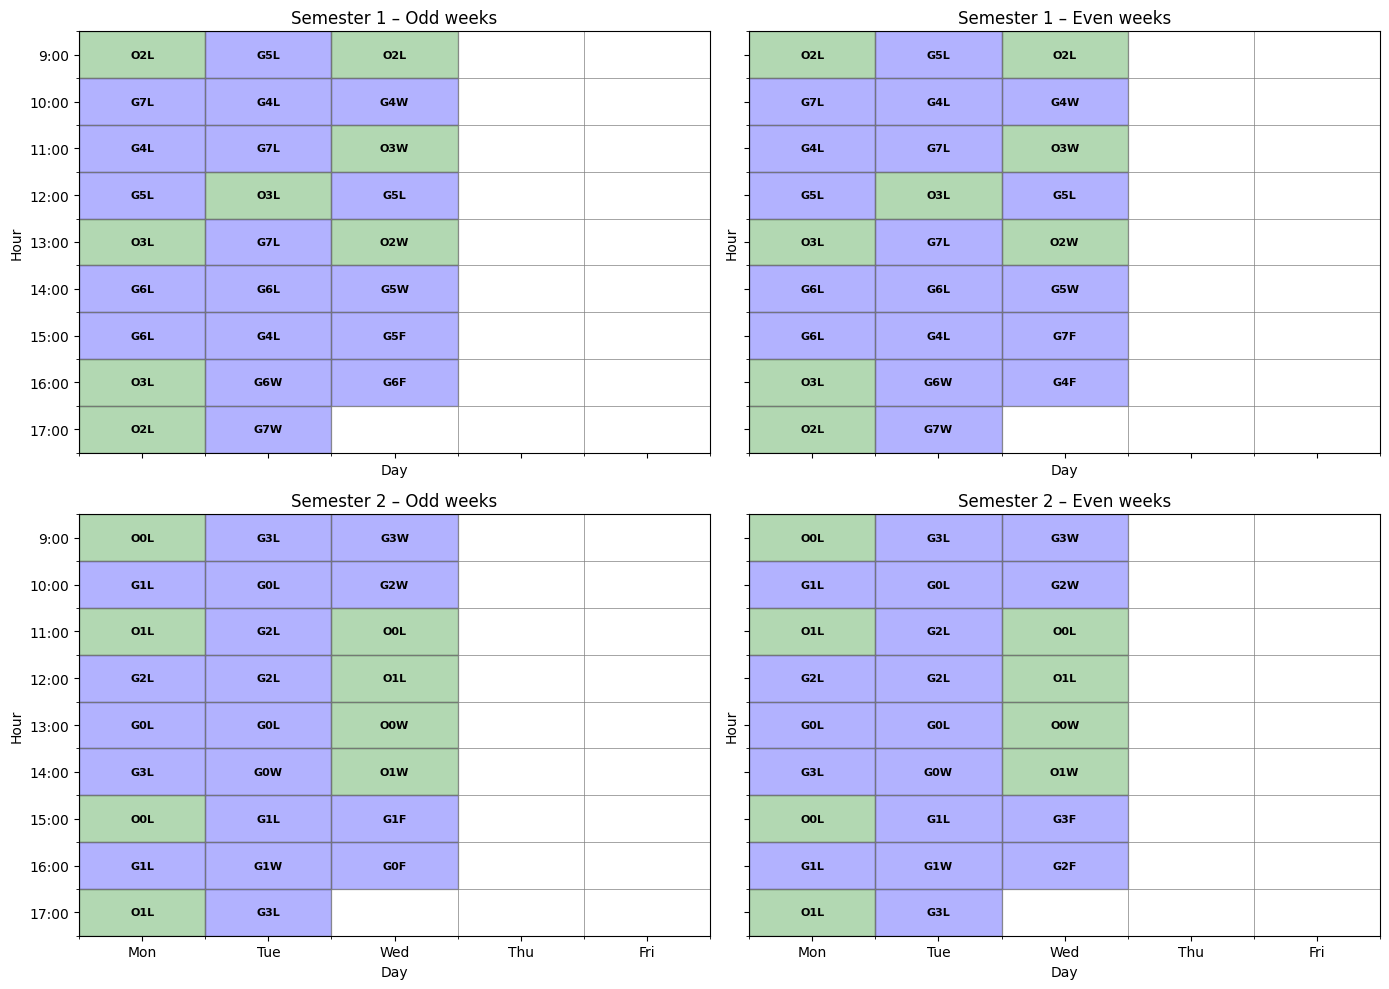

In [19]:
import matplotlib.pyplot as plt
import numpy as np
xL_sol = {k: m.getSolution(v) for k, v in xL.items()}
xW_sol = {k: m.getSolution(v) for k, v in xW.items()}
xF_sol = {k: m.getSolution(v) for k, v in xF.items()}
yL_sol = {k: m.getSolution(v) for k, v in yL.items()}
yW_sol = {k: m.getSolution(v) for k, v in yW.items()}
z_sol  = {k: m.getSolution(v) for k, v in z.items()}
w_sol  = {k: m.getSolution(v) for k, v in w.items()}
    # -------------------------------------------------------------------
    # Visualisation function
    # -------------------------------------------------------------------
def plot_timetable():
        # Create a 2x2 grid: rows = semesters, cols = week parity
        fig, axes = plt.subplots(len(S), len(W), figsize=(14, 10), sharex=True, sharey=True)
        if len(S) == 1 and len(W) == 1:
            axes = np.array([[axes]])
        elif len(S) == 1 or len(W) == 1:
            axes = axes.reshape(len(S), len(W))
        
        day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'] if num_days == 5 else [f'D{d}' for d in D]
        hour_labels = [f'{9+h}:00' for h in H]  # assuming start at 9am

        for i_s, s in enumerate(S):
            for i_w, w_par in enumerate(W):
                ax = axes[i_s, i_w]
                ax.set_title(f'Semester {s} – {"Odd" if w_par==1 else "Even"} weeks')
                ax.set_xlabel('Day')
                ax.set_ylabel('Hour')
                ax.set_xticks(np.arange(len(D)))
                ax.set_xticklabels(day_labels)
                ax.set_yticks(np.arange(len(H)))
                ax.set_yticklabels(hour_labels)
                ax.set_xlim(-0.5, len(D)-0.5)
                ax.set_ylim(-0.5, len(H)-0.5)
                ax.invert_yaxis()  # so hour 0 (9am) is at top

                # Draw grid lines
                ax.set_xticks(np.arange(-0.5, len(D), 1), minor=True)
                ax.set_yticks(np.arange(-0.5, len(H), 1), minor=True)
                ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

                # Scan all time slots
                for d in D:
                    for h in H:
                        # Collect all events at (d,h,s,w_par)
                        labels = []
                        colors = []
                        # Gateway lectures & weekly workshops (they occur in both weeks)
                        for g in G:
                            if xL_sol.get((g,d,h,s), 0) > 0.5:
                                labels.append(f'G{g}L')
                                colors.append('blue')
                            if xW_sol.get((g,d,h,s), 0) > 0.5:
                                labels.append(f'G{g}W')
                                colors.append('blue')
                            # Fortnightly workshop (depends on w_par)
                            if xF_sol.get((g,d,h,s,w_par), 0) > 0.5:
                                labels.append(f'G{g}F')
                                colors.append('blue')
                        # Optional courses
                        for o in O:
                            if yL_sol.get((o,d,h,s), 0) > 0.5:
                                labels.append(f'O{o}L')
                                colors.append('green')
                            if yW_sol.get((o,d,h,s), 0) > 0.5:
                                labels.append(f'O{o}W')
                                colors.append('green')

                        # If there is an event, draw a coloured rectangle with label
                        if labels:
                            # Combine multiple events (should not happen due to constraint)
                            text = '\n'.join(labels)
                            # Use the color of the first event (all same color if same course type)
                            color = colors[0] if colors else 'gray'
                            rect = plt.Rectangle((d-0.5, h-0.5), 1, 1,
                                                 facecolor=color, alpha=0.3, edgecolor='black')
                            ax.add_patch(rect)
                            ax.text(d, h, text, ha='center', va='center',
                                    fontsize=8, weight='bold')

        plt.tight_layout()
        plt.show()

    # Call the plotting function
plot_timetable()

C:\Users\frequensy\AppData\Local\Temp\ipykernel_6824\2204610740.py:49: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xL = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_6824\2204610740.py:50: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xW = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_6824\2204610740.py:51: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xF = {(g, d, h, s, w): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S for w in W}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_6824\2204610740.py:52: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  yL = 

FICO Xpress v9.7.0, Hyper, solve started 0:33:58, Mar 19, 2026
Heap usage: 3755KB (peak 3755KB, 237KB system)
Minimizing MILP noname using up to 8 threads and up to 7975MB memory, with these control settings:
OUTPUTLOG = 1
NLPPOSTSOLVE = 1
XSLP_DELETIONCONTROL = 0
XSLP_OBJSENSE = 1
Original problem has:
      5252 rows         3784 cols        50016 elements      3644 entities
Presolved problem has:
      1688 rows         3832 cols        34610 elements      3632 entities
LP relaxation tightened
Presolve finished in 0 seconds
Heap usage: 7393KB (peak 9267KB, 237KB system)

Coefficient range                    original                 solved        
  Coefficients   [min,max] : [ 1.00e+00,  9.00e+00] / [ 1.25e-01,  1.50e+00]
  RHS and bounds [min,max] : [ 1.00e+00,  4.00e+00] / [ 1.00e+00,  4.00e+00]
  Objective      [min,max] : [ 9.30e-03,  8.34e-01] / [ 9.30e-03,  8.34e-01]
Autoscaling applied standard scaling

Symmetric problem: generators: 16, support set: 3788
 Number of orbits: 2

C:\Users\frequensy\AppData\Local\Temp\ipykernel_6824\2204610740.py:189: DeprecationWarning: Deprecated in Xpress 9.5: use problem.attributes.solvestatus and problem.attributes.solstatus instead
  status = m.getProbStatusString().lower()
C:\Users\frequensy\AppData\Local\Temp\ipykernel_6824\2204610740.py:193: DeprecationWarning: Deprecated in Xpress 9.5: use problem.attributes.objval instead
  print(f"Objective value: {m.getObjVal():.2f}")


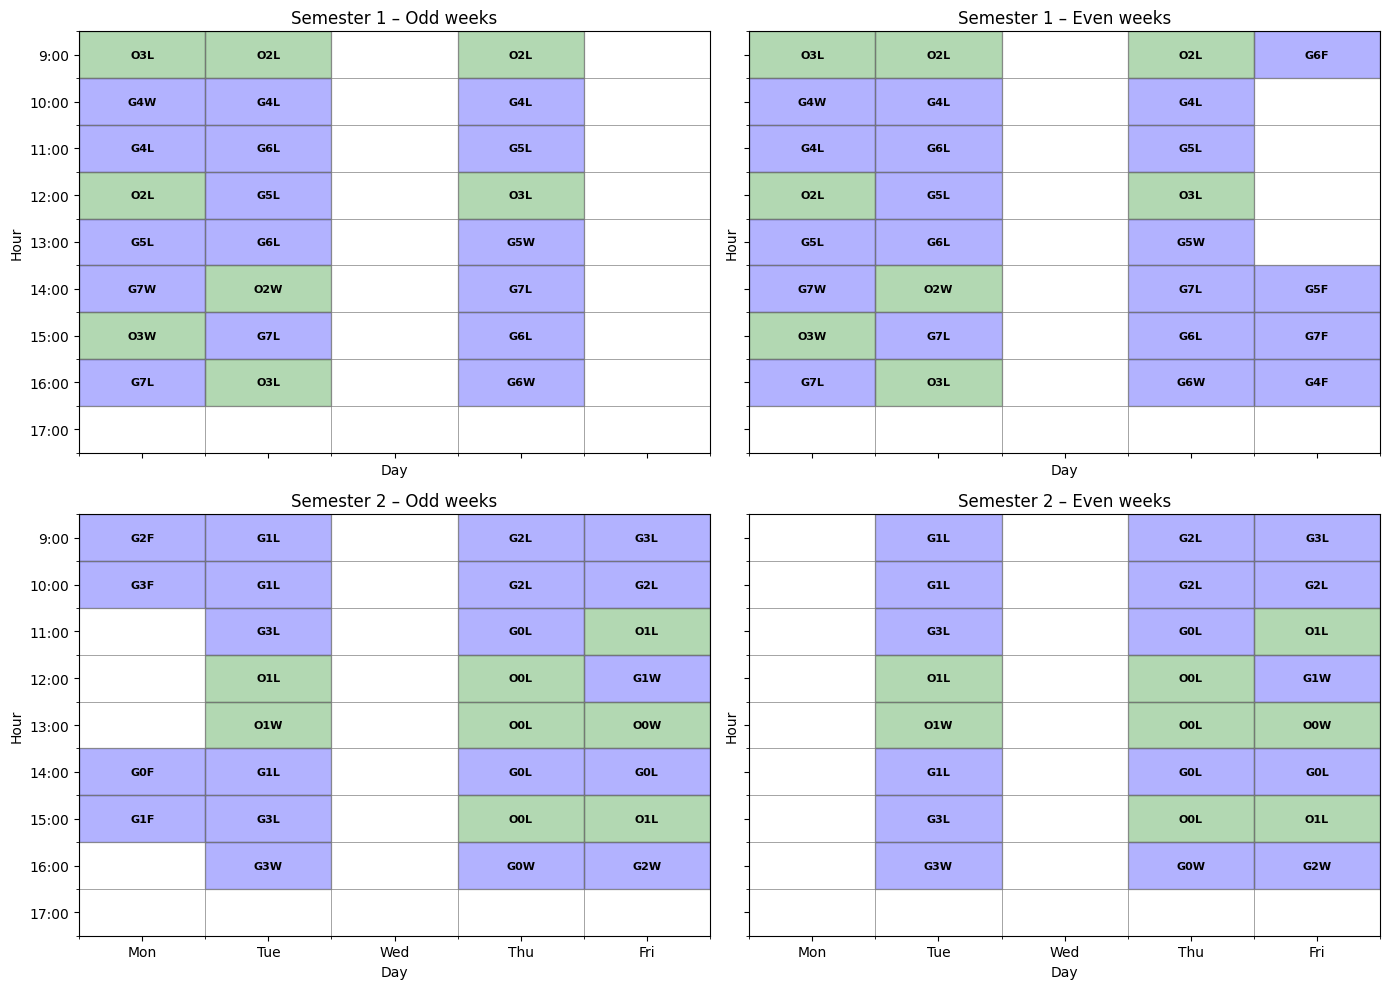

In [3]:
import xpress as xp
from xpress import constants
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# User-defined parameters (adjust as needed)
# -------------------------------------------------------------------
num_gateway = 8
num_optional = 4
num_days = 5
num_hours = 9  # hours 0..8 correspond to 9am..5pm

RgL = 3
RgW = 1
RgF = 1
RoL = 3
RoW = 1
Cg = 4
Co = 2

# Soft constraint weights (replace with your estimated values)
lambda_late = 0.3669  # after 5pm
lambda_lunch = 0.0093  # lunch time
lambda_isolated = 0.4530  # isolated class
lambda_days = 0.1002  # number of days
lambda_wed = 0.05  # Wednesday after 1pm (set your own if needed)

# -------------------------------------------------------------------
# Sets
# -------------------------------------------------------------------
G = range(num_gateway)
O = range(num_optional)
S = [1, 2]
D = range(num_days)
H = range(num_hours)
W = [1, 2]  # week parity (1 = odd, 2 = even)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
wed_idx = 2  # Wednesday index

# -------------------------------------------------------------------
# Problem
# -------------------------------------------------------------------
m = xp.problem("timetabling")

# -------------------------------------------------------------------
# Decision variables (hard constraints)
# -------------------------------------------------------------------
xL = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
xW = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
xF = {(g, d, h, s, w): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S for w in W}
yL = {(o, d, h, s): xp.var(vartype=xp.binary) for o in O for d in D for h in H for s in S}
yW = {(o, d, h, s): xp.var(vartype=xp.binary) for o in O for d in D for h in H for s in S}
z = {(g, s): xp.var(vartype=xp.binary) for g in G for s in S}
w = {(o, s): xp.var(vartype=xp.binary) for o in O for s in S}

# -------------------------------------------------------------------
# Variables for soft constraints
# -------------------------------------------------------------------
# Isolated indicator (for each day, hour 1..7, semester, week)
h_isol = [h for h in H if 1 <= h <= 7]
is_isolated = {(d, h, s, w): xp.var(vartype=xp.continuous, lb=0, ub=1)
               for d in D for h in h_isol for s in S for w in W}

# Day used indicator (binary)
b = {(d, s, w): xp.var(vartype=xp.binary) for d in D for s in S for w in W}

# Collect all variables
all_vars = (list(xL.values()) + list(xW.values()) + list(xF.values()) +
            list(yL.values()) + list(yW.values()) + list(z.values()) + list(w.values()) +
            list(is_isolated.values()) + list(b.values()))
m.addVariable(all_vars)

# -------------------------------------------------------------------
# Hard constraints (unchanged)
# -------------------------------------------------------------------
for g in G:
    m.addConstraint(xp.Sum(z[g, s] for s in S) == 1)
for o in O:
    m.addConstraint(xp.Sum(w[o, s] for s in S) == 1)

for s in S:
    m.addConstraint(xp.Sum(z[g, s] for g in G) == Cg)
    m.addConstraint(xp.Sum(w[o, s] for o in O) == Co)

for g in G:
    for s in S:
        m.addConstraint(xp.Sum(xL[g, d, h, s] for d in D for h in H) == RgL * z[g, s])
        m.addConstraint(xp.Sum(xW[g, d, h, s] for d in D for h in H) == RgW * z[g, s])
for o in O:
    for s in S:
        m.addConstraint(xp.Sum(yL[o, d, h, s] for d in D for h in H) == RoL * w[o, s])
        m.addConstraint(xp.Sum(yW[o, d, h, s] for d in D for h in H) == RoW * w[o, s])

for g in G:
    m.addConstraint(xp.Sum(xF[g, d, h, s, w_par] for d in D for h in H for s in S for w_par in W) == 1)

# No multiple events per course in same slot
for g in G:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(xL[g, d, h, s] + xW[g, d, h, s] +
                                xp.Sum(xF[g, d, h, s, w_par] for w_par in W) <= 1)
for o in O:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(yL[o, d, h, s] + yW[o, d, h, s] <= 1)

# Global no‑clash per week
for d in D:
    for h in H:
        for s in S:
            for w_par in W:
                m.addConstraint(
                    xp.Sum(xL[g, d, h, s] for g in G) +
                    xp.Sum(xW[g, d, h, s] for g in G) +
                    xp.Sum(yL[o, d, h, s] for o in O) +
                    xp.Sum(yW[o, d, h, s] for o in O) +
                    xp.Sum(xF[g, d, h, s, w_par] for g in G) <= 1
                )

# Events only in assigned semester
for g in G:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(xL[g, d, h, s] <= z[g, s])
                m.addConstraint(xW[g, d, h, s] <= z[g, s])
                for w_par in W:
                    m.addConstraint(xF[g, d, h, s, w_par] <= z[g, s])
for o in O:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(yL[o, d, h, s] <= w[o, s])
                m.addConstraint(yW[o, d, h, s] <= w[o, s])


# -------------------------------------------------------------------
# Soft constraints
# -------------------------------------------------------------------

# Helper: event presence at a given (d,h,s,w) – used repeatedly
def event_present(d, h, s, w):
    return (xp.Sum(xL[g, d, h, s] for g in G) +
            xp.Sum(xW[g, d, h, s] for g in G) +
            xp.Sum(yL[o, d, h, s] for o in O) +
            xp.Sum(yW[o, d, h, s] for o in O) +
            xp.Sum(xF[g, d, h, s, w] for g in G))


# 1. Isolated classes (for hours 1..7)
for d in D:
    for s in S:
        for w_par in W:
            for h in h_isol:
                ev_h = event_present(d, h, s, w_par)
                ev_hp1 = event_present(d, h + 1, s, w_par)
                ev_hm1 = event_present(d, h - 1, s, w_par)
                m.addConstraint(is_isolated[d, h, s, w_par] >= ev_h - ev_hp1 - ev_hm1)
                m.addConstraint(is_isolated[d, h, s, w_par] <= ev_h)

# 2. Days used per week
for d in D:
    for s in S:
        for w_par in W:
            total_day = xp.Sum(event_present(d, h, s, w_par) for h in H)
            m.addConstraint(b[d, s, w_par] <= total_day)
            m.addConstraint(total_day <= len(H) * b[d, s, w_par])

# -------------------------------------------------------------------
# Objective
# -------------------------------------------------------------------
obj_late = lambda_late * xp.Sum(event_present(d, 8, s, w_par) for d in D for s in S for w_par in W)
obj_lunch = lambda_lunch * xp.Sum(event_present(d, h, s, w_par) for d in D for s in S for w_par in W for h in [3, 4])
obj_isol = lambda_isolated * xp.Sum(is_isolated[d, h, s, w_par] for d in D for h in h_isol for s in S for w_par in W)
obj_days = lambda_days * xp.Sum(b[d, s, w_par] for d in D for s in S for w_par in W)
obj_wed = lambda_wed * xp.Sum(event_present(wed_idx, h, s, w_par) for h in range(4, 9) for s in S for w_par in W)

objective = obj_late + obj_lunch + obj_isol + obj_days + obj_wed
m.setObjective(objective, sense=xp.minimize)

# -------------------------------------------------------------------
# Solve
# -------------------------------------------------------------------
m.solve()
status = m.getProbStatusString().lower()

if 'optimal' in status or 'feasible' in status:
    print("Optimal (or feasible) timetable found!")
    print(f"Objective value: {m.getObjVal():.2f}")

    # Print semester assignments
    for g in G:
        for s in S:
            if m.getSolution(z[g, s]) > 0.5:
                print(f"Gateway course {g} runs in semester {s}")
    for o in O:
        for s in S:
            if m.getSolution(w[o, s]) > 0.5:
                print(f"Optional course {o} runs in semester {s}")

    # Retrieve solutions for plotting
    xL_sol = {k: m.getSolution(v) for k, v in xL.items()}
    xW_sol = {k: m.getSolution(v) for k, v in xW.items()}
    xF_sol = {k: m.getSolution(v) for k, v in xF.items()}
    yL_sol = {k: m.getSolution(v) for k, v in yL.items()}
    yW_sol = {k: m.getSolution(v) for k, v in yW.items()}
    z_sol = {k: m.getSolution(v) for k, v in z.items()}
    w_sol = {k: m.getSolution(v) for k, v in w.items()}


    # Plot timetable (same as before)
    def plot_timetable():
        fig, axes = plt.subplots(len(S), len(W), figsize=(14, 10), sharex=True, sharey=True)
        if len(S) == 1 and len(W) == 1:
            axes = np.array([[axes]])
        elif len(S) == 1 or len(W) == 1:
            axes = axes.reshape(len(S), len(W))

        day_labels = day_names if num_days == 5 else [f'D{d}' for d in D]
        hour_labels = [f'{9 + h}:00' for h in H]

        for i_s, s in enumerate(S):
            for i_w, w_par in enumerate(W):
                ax = axes[i_s, i_w]
                ax.set_title(f'Semester {s} – {"Odd" if w_par == 1 else "Even"} weeks')
                ax.set_xlabel('Day')
                ax.set_ylabel('Hour')
                ax.set_xticks(np.arange(len(D)))
                ax.set_xticklabels(day_labels)
                ax.set_yticks(np.arange(len(H)))
                ax.set_yticklabels(hour_labels)
                ax.set_xlim(-0.5, len(D) - 0.5)
                ax.set_ylim(-0.5, len(H) - 0.5)
                ax.invert_yaxis()
                ax.set_xticks(np.arange(-0.5, len(D), 1), minor=True)
                ax.set_yticks(np.arange(-0.5, len(H), 1), minor=True)
                ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

                for d in D:
                    for h in H:
                        labels = []
                        colors = []
                        for g in G:
                            if xL_sol.get((g, d, h, s), 0) > 0.5:
                                labels.append(f'G{g}L')
                                colors.append('blue')
                            if xW_sol.get((g, d, h, s), 0) > 0.5:
                                labels.append(f'G{g}W')
                                colors.append('blue')
                            if xF_sol.get((g, d, h, s, w_par), 0) > 0.5:
                                labels.append(f'G{g}F')
                                colors.append('blue')
                        for o in O:
                            if yL_sol.get((o, d, h, s), 0) > 0.5:
                                labels.append(f'O{o}L')
                                colors.append('green')
                            if yW_sol.get((o, d, h, s), 0) > 0.5:
                                labels.append(f'O{o}W')
                                colors.append('green')
                        if labels:
                            text = '\n'.join(labels)
                            color = colors[0] if colors else 'gray'
                            rect = plt.Rectangle((d - 0.5, h - 0.5), 1, 1,
                                                 facecolor=color, alpha=0.3, edgecolor='black')
                            ax.add_patch(rect)
                            ax.text(d, h, text, ha='center', va='center',
                                    fontsize=8, weight='bold')
        plt.tight_layout()
        plt.show()


    plot_timetable()

else:
    print("No feasible solution found. Check constraints.")